In [2]:
# Menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
path = "/content/gdrive/MyDrive/Semester_7/praktikum_ml/praktikum05/"

In [4]:
# 1. Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
# 2. Load dataset Iris
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("=== 5 Data Teratas ===")
print(df.head())
print("\n=== Informasi Dataset ===")
print(df.info())

=== 5 Data Teratas ===
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   specie

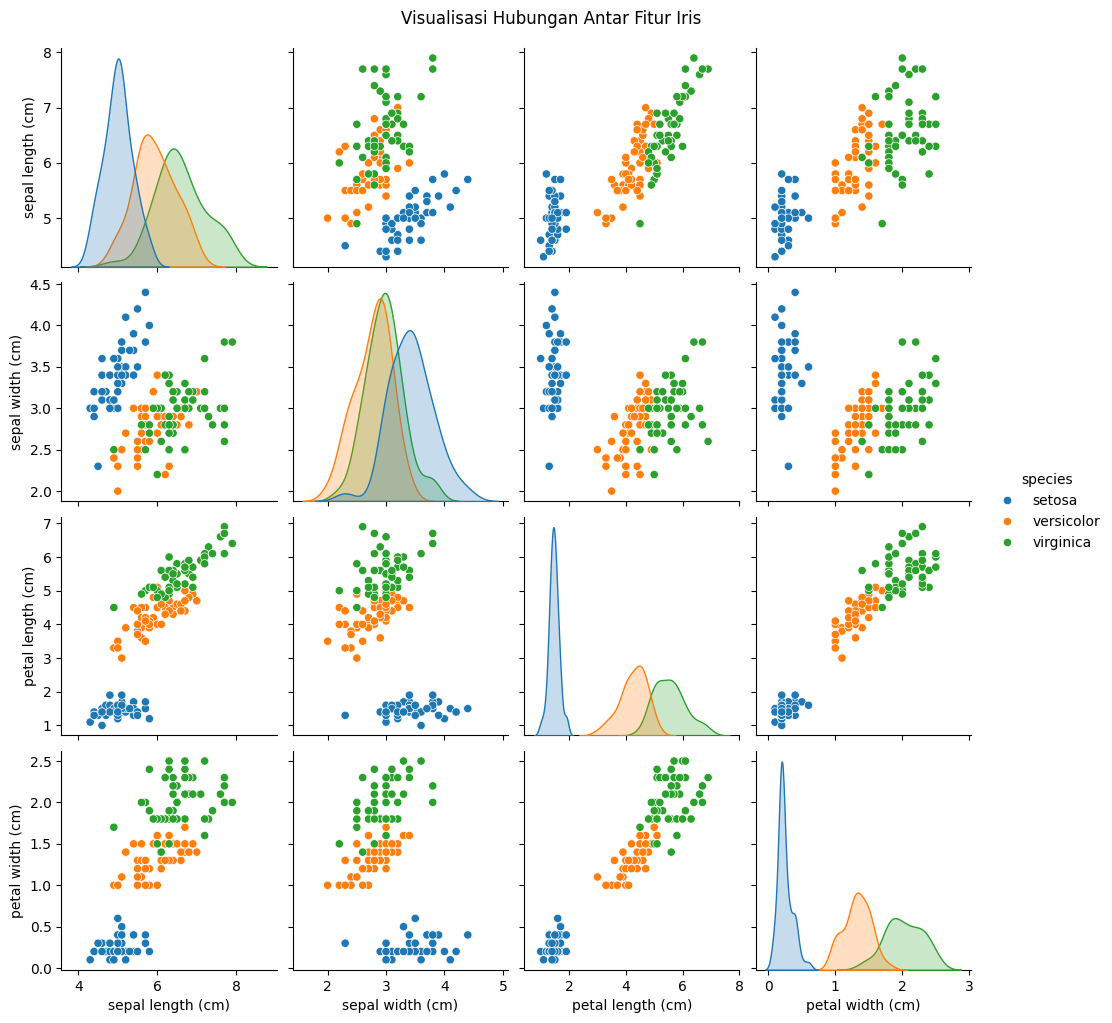

In [6]:
# 3. Visualisasi sebaran data
sns.pairplot(df, hue='species')
plt.suptitle("Visualisasi Hubungan Antar Fitur Iris", y=1.02)
plt.show()

In [7]:
# 4. Pisahkan variabel independen (X) dan dependen (y)
X = df.drop(columns=['species'])
y = df['species']

In [8]:
# 5. Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data testing : {len(X_test)}")

Jumlah data training: 120
Jumlah data testing : 30


In [9]:
# 6. Membuat model Decision Tree
model = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [10]:
# 7. Evaluasi model
y_pred = model.predict(X_test)

print("\n=== Evaluasi Model Decision Tree ===")
print(f"Akurasi Model: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


=== Evaluasi Model Decision Tree ===
Akurasi Model: 93.33%

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



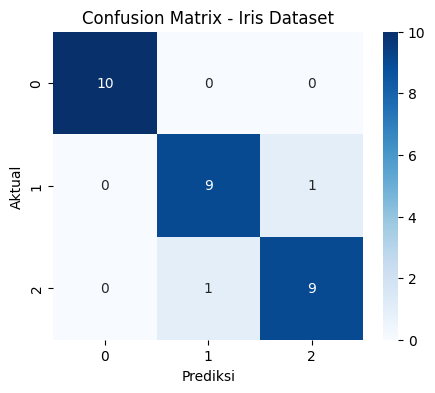

In [11]:
# 8. Visualisasi Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix - Iris Dataset")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

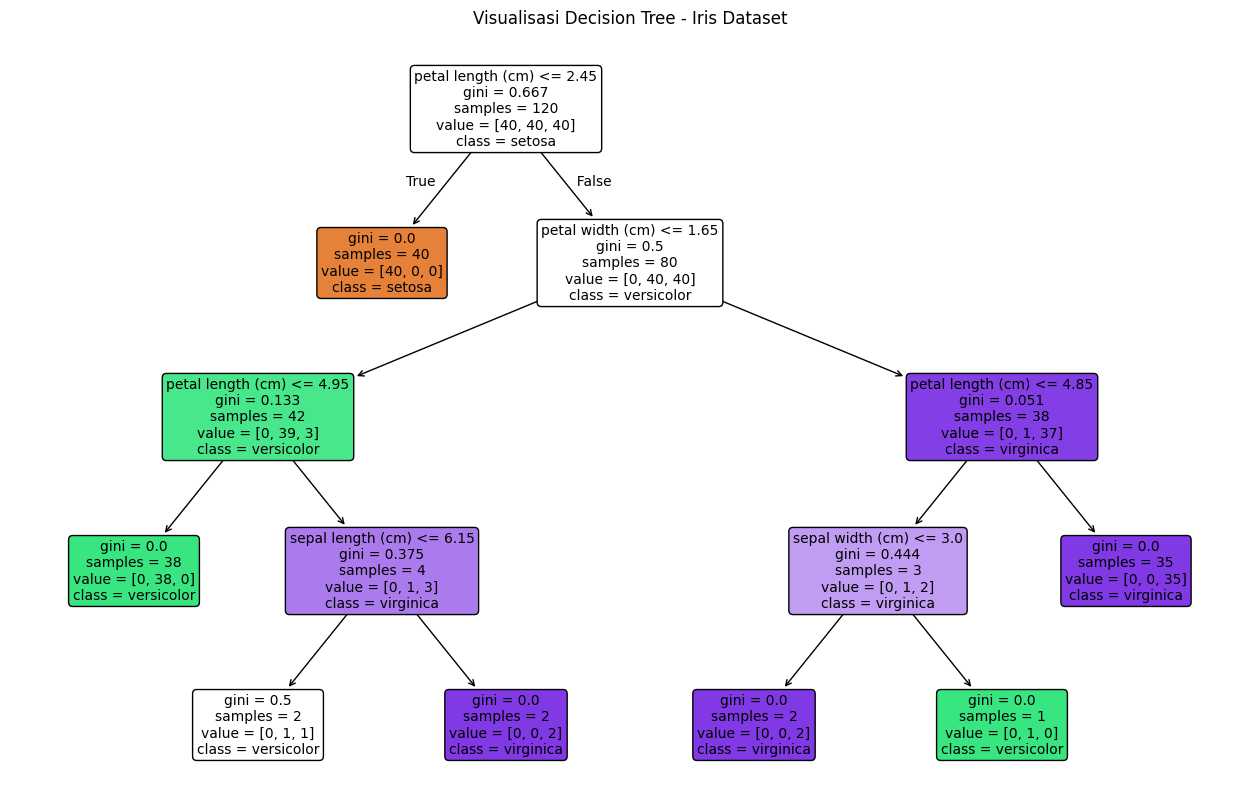

In [12]:
# 9. Visualisasi Struktur Pohon Keputusan
plt.figure(figsize=(16, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Visualisasi Decision Tree - Iris Dataset")
plt.show()

In [13]:
# 10. Pengujian Model Menggunakan Data Testing
hasil = pd.DataFrame({
    "Data Aktual": y_test,
    "Data Prediksi": y_pred
})
print("\n=== Hasil Prediksi pada Data Testing ===")
print(hasil.head(10))


=== Hasil Prediksi pada Data Testing ===
    Data Aktual Data Prediksi
38       setosa        setosa
127   virginica     virginica
57   versicolor    versicolor
93   versicolor    versicolor
42       setosa        setosa
56   versicolor    versicolor
22       setosa        setosa
20       setosa        setosa
147   virginica     virginica
84   versicolor    versicolor
